In [1]:
%matplotlib widget
import numpy as np                          # numerical computing
import matplotlib.pyplot as plt             # plotting
import pandas as pd                         # data manipluation

from sklearn.datasets import make_blobs     # synthetic cluster data
from sklearn.cluster import KMeans          # K-Means baseline
from sklearn.mixture import GaussianMixture # GMM from scikit-learn
from matplotlib.patches import Ellipse      # draw covariance ellipses
from scipy.spatial.distance import cdist    # pairwise distances
from scipy.stats import norm                # 1-D Gaussian pdf


In [2]:
cod_df = pd.read_csv("./data/Multiple_Cause_of_Death_1999-2020-2.csv") # Multiple Causes of Death
adrd_df = pd.read_csv("./data/Accidental_Drug_Related_Deaths_2012-2024_20260423.csv") # State of Conneticut
nchs_df = pd.read_csv("./data/NCHS_-_Drug_Poisoning_Mortality_by_State__United_States_20260423.csv") # Drug poisoning by state

# [].unique()
# cod_df
adrd_df['Sex'].unique()
# nchs_df['Race and Hispanic Origin'].unique()

array(['Male', 'Female', nan, 'Unknown', 'X'], dtype=object)

In [3]:
## CLeaning Multiple Cause of Death dataframe
# Remove any columns with notes as they contain no information to our data 
# check = cod_df[cod_df["Notes"].notna()]
# print(check)
cleaned_cod_df = cod_df.iloc[:6235].drop(columns=["Notes"])

# Then clean our data so that we only include cases of drug deaths (so ignoring alchohl and other deaths)
cleaned_cod_df = cleaned_cod_df.rename(columns={"UCD - Drug/Alcohol Induced Cause": "Cause", "UCD - Drug/Alcohol Induced Cause Code": "Cause Codes"})
arr = cleaned_cod_df["Cause Codes"].unique()
# print(f"Array of unique cause codes: {arr}")
cleaned_cod_df = cleaned_cod_df[(cleaned_cod_df["Cause Codes"] == 'D1') | 
                        (cleaned_cod_df["Cause Codes"] == 'D2') | 
                        (cleaned_cod_df["Cause Codes"] == 'D3') | 
                        (cleaned_cod_df["Cause Codes"] == 'D4') | 
                        (cleaned_cod_df["Cause Codes"] == 'D9')]
# cleaned_df.info()
cleaned_cod_df = cleaned_cod_df.drop(columns=["Year Code", "Race Code", "Sex Code"])
# cleaned_cod_df = cleaned_cod_df[cleaned_cod_df[Sex'']]
# cleaned_cod_df


cleaned_cod_df[cleaned_cod_df['Population'] == 'Not Applicable']
cleaned_cod_df = cleaned_cod_df.drop([1008, 1034])
cleaned_cod_df['Population'] = cleaned_cod_df['Population'].astype(float)
# cleaned_cod_df.info()

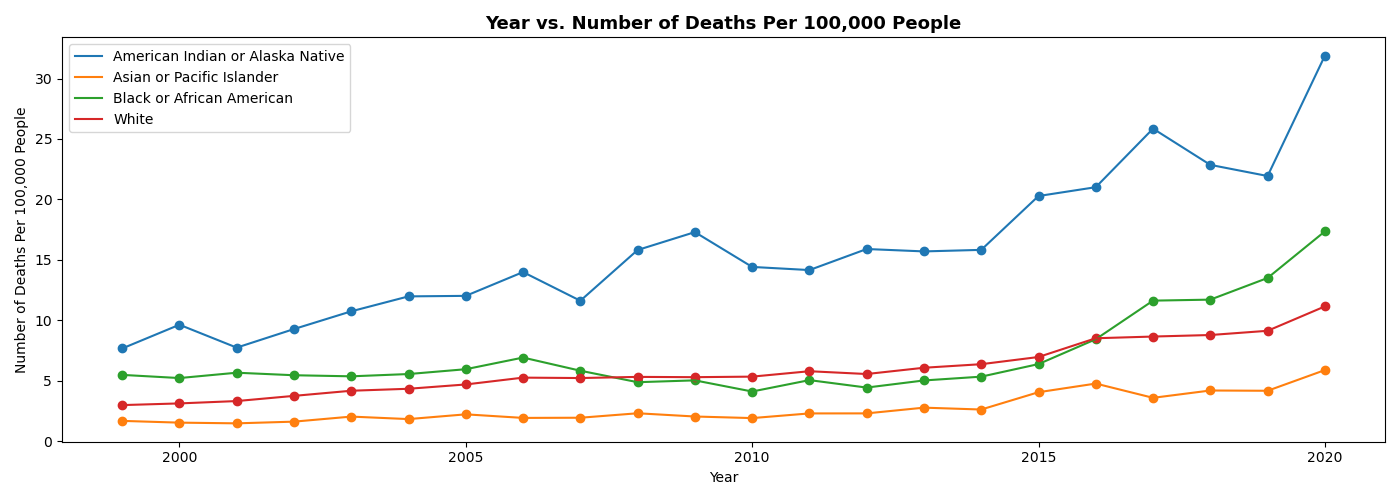

In [4]:
fig, axes = plt.subplots(1, 1, figsize=(14, 5))

new_df = cleaned_cod_df[(cleaned_cod_df['Sex'] == 'Male')][['Year', 'Race', 'Sex', 'Deaths', 'Population']]

new_df = new_df.groupby(['Year', 'Race'], as_index=False).agg({'Deaths':'sum', 'Population':'sum'})

for race_var in new_df['Race'].unique():
    x1 = new_df[new_df['Race'] == race_var]["Year"]
    y1 = new_df[new_df['Race'] == race_var]["Deaths"] / new_df[new_df['Race'] == race_var]["Population"] * 100000
    axes.scatter(x1, y1)
    axes.plot(x1, y1, label=f'{race_var}')

axes.set_title("Year vs. Number of Deaths Per 100,000 People", fontweight='bold', fontsize=13)
axes.set_xlabel("Year")
axes.set_ylabel("Number of Deaths Per 100,000 People")
axes.legend()
plt.tight_layout()
plt.show()

In [5]:
## CLeaning Accidental Drug Related Deaths dataframe
# cleaned_adrd_df = adrd_df[adrd_df["Sex"] == "Male"]
cleaned_adrd_df = adrd_df.sort_values(by='Date')
cleaned_adrd_df['Date'] = pd.to_datetime(cleaned_adrd_df['Date'])
cleaned_adrd_df = cleaned_adrd_df.dropna(subset=['Age'])
list_of_drugs = ['Heroin', 'Cocaine', 'Fentanyl', 
                 'Fentanyl Analogue', 'Oxycodone',
                 'Oxymorphone', 'Ethanol', 
                 'Hydrocodone', 'Benzodiazepine', 
                 'Methadone', 'Meth/Amphetamine', 
                 'Amphet', 'Tramad', 'Hydromorphone',
                 'Morphine (Not Heroin)', 'Xylazine', 
                 'Gabapentin', 'Opiate NOS', 'Heroin/Morph/Codeine', 
                 'Other Opioid']

cleaned_adrd_df[list_of_drugs] = cleaned_adrd_df[list_of_drugs].fillna(0)
for drug in list_of_drugs:
    cleaned_adrd_df[f'{drug}'] = [1 if x == 'Y' else 0 for x in cleaned_adrd_df[f'{drug}']]

cleaned_adrd_df['Drug Count'] = cleaned_adrd_df[['Heroin', 'Cocaine', 'Fentanyl', 
                                                 'Fentanyl Analogue', 'Oxycodone',
                                                 'Oxymorphone', 'Ethanol', 
                                                 'Hydrocodone', 'Benzodiazepine', 
                                                 'Methadone', 'Meth/Amphetamine', 
                                                 'Amphet', 'Tramad', 'Hydromorphone',
                                                 'Morphine (Not Heroin)', 'Xylazine', 
                                                 'Gabapentin', 'Opiate NOS', 'Heroin/Morph/Codeine', 
                                                 'Other Opioid']].sum(axis=1)
epoch = pd.to_datetime('2012-01-01')
cleaned_adrd_df['Days since 2012-Jan-01'] = (cleaned_adrd_df['Date']-epoch).dt.days
# df['status'] = ['Pass' if x >= 70 else 'Fail' for x in df['grade']]
# cleaned_adrd_df = cleaned_adrd_df[cleaned_adrd_df['Date Type'] == 'Date reported']
# cleaned_adrd_df['Cause of Death']
# cleaned_adrd_df['Date'].unique()
cleaned_adrd_df.info()
# cleaned_adrd_df

<class 'pandas.core.frame.DataFrame'>
Index: 12961 entries, 3026 to 12728
Data columns (total 50 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Date                           12961 non-null  datetime64[ns]
 1   Date Type                      12961 non-null  object        
 2   Age                            12961 non-null  float64       
 3   Sex                            12953 non-null  object        
 4   Race                           12896 non-null  object        
 5   Ethnicity                      3435 non-null   object        
 6   Residence City                 12319 non-null  object        
 7   Residence County               11654 non-null  object        
 8   Residence State                10926 non-null  object        
 9   Injury City                    12705 non-null  object        
 10  Injury County                  9526 non-null   object        
 11  Injury State     

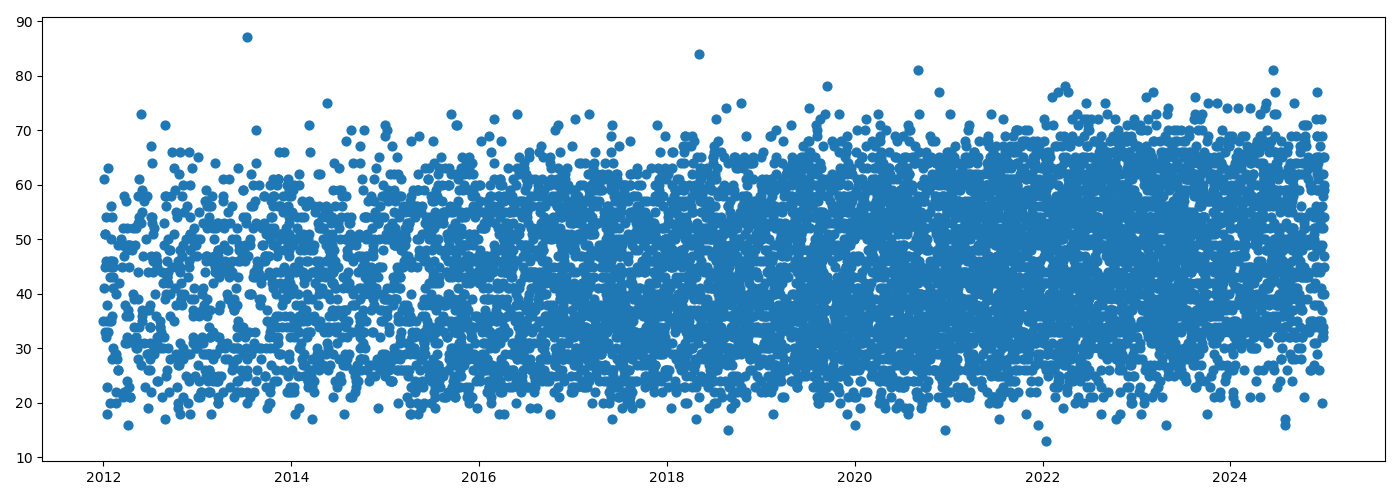

In [6]:
cleaned_adrd_df = cleaned_adrd_df[cleaned_adrd_df['Sex'] == 'Male']

fig, axes = plt.subplots(1, 1, figsize=(14, 5))

x_vals = cleaned_adrd_df["Date"]
y_vals = cleaned_adrd_df["Age"]
axes.scatter(x_vals, y_vals, s=40)

plt.tight_layout()
plt.show()

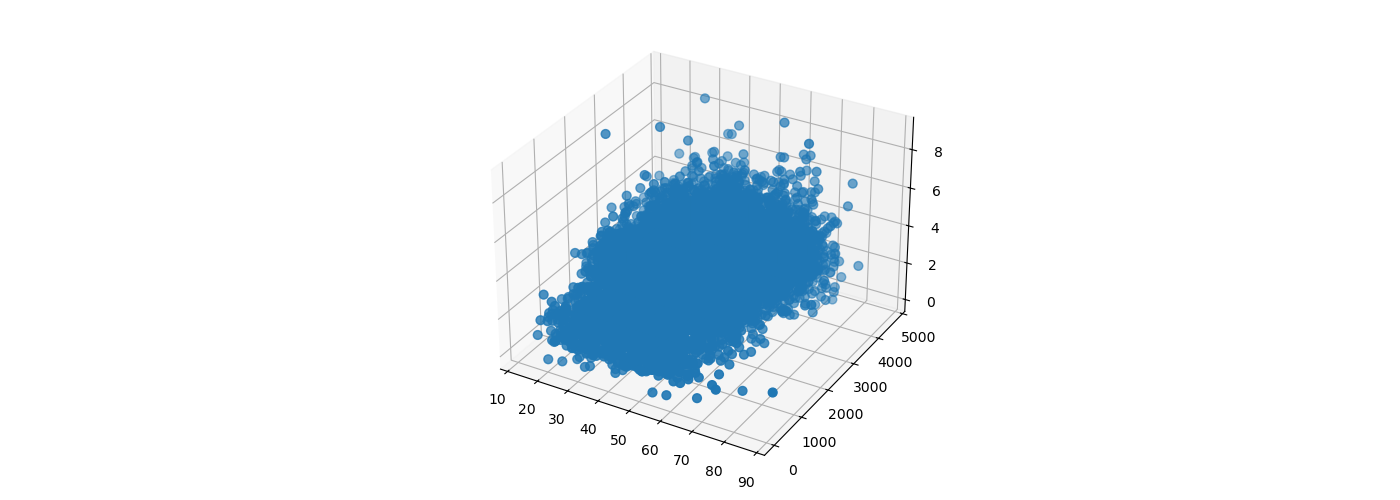

In [7]:
cleaned_adrd_df = cleaned_adrd_df[cleaned_adrd_df['Sex'] == 'Male']

fig = plt.figure(figsize=(14, 5))
axes = fig.add_subplot(projection='3d')

x_vals = cleaned_adrd_df["Age"]
y_vals = cleaned_adrd_df["Days since 2012-Jan-01"]
z_vals = cleaned_adrd_df["Drug Count"]

axes.scatter(x_vals, y_vals, z_vals, s=40)

plt.tight_layout()
plt.show()

In [8]:
def draw_ellipse(ax, mean, cov, color, label=''):
    """
    Given a 2x2 covariance matrix, draw the ellipse that contains
    ~95% of the probability mass (2 standard deviations).
    """
    vals, vecs = np.linalg.eigh(cov)              # eigenvalues & eigenvectors
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))  # rotation angle
    w, h = 2 * 2 * np.sqrt(vals)                  # width/height at 2-sigma
    ell = Ellipse(xy=mean, width=w, height=h, angle=angle,
                  ec=color, fc=color, alpha=0.25, lw=2, label=label)
    ax.add_patch(ell)
    ax.plot(*mean, 'o', color=color, ms=8, zorder=5)  # mark the mean


# cleaned_adrd_df.info()

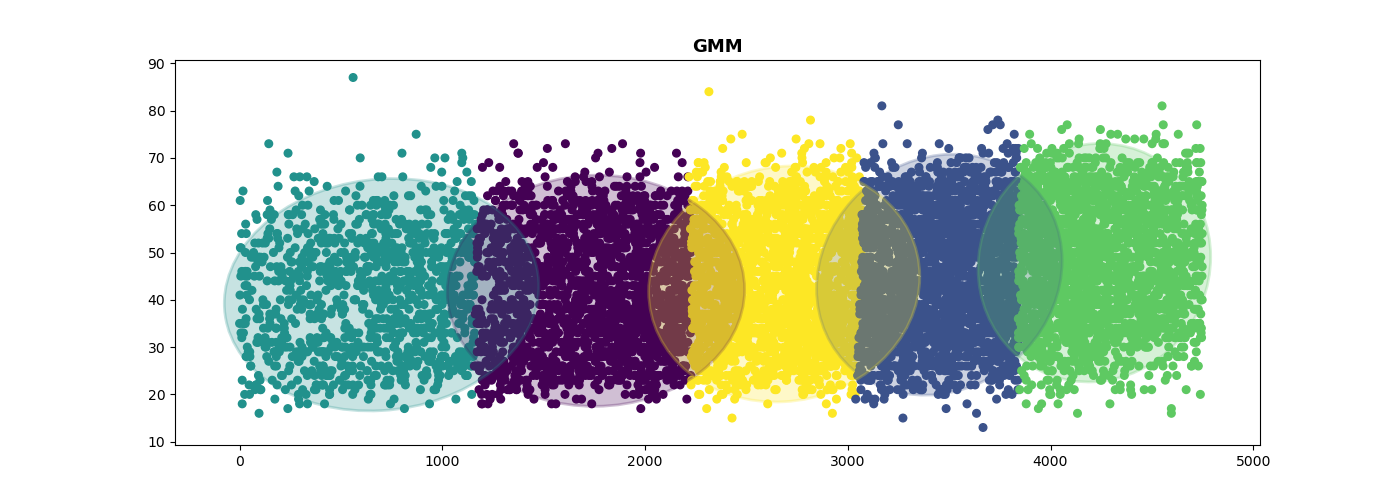

In [9]:
n = 5
gmm = GaussianMixture(n_components=n,        # K = n components
                       covariance_type='full', 
                       random_state=21)

labels_gmm = gmm.fit_predict(cleaned_adrd_df[['Days since 2012-Jan-01', 'Age']])

fig, axes = plt.subplots(1, 1, figsize=(14, 5))
axes.scatter(cleaned_adrd_df['Days since 2012-Jan-01'], cleaned_adrd_df['Age'], c=labels_gmm, s=30, cmap='viridis')
colors = plt.cm.viridis(np.linspace(0, 1, n))
for k in range(n):
#     # Overlay the learned covariance ellipse for each component
    draw_ellipse(axes, gmm.means_[k], gmm.covariances_[k], colors[k])
axes.set_title("GMM", fontweight='bold', fontsize=13);

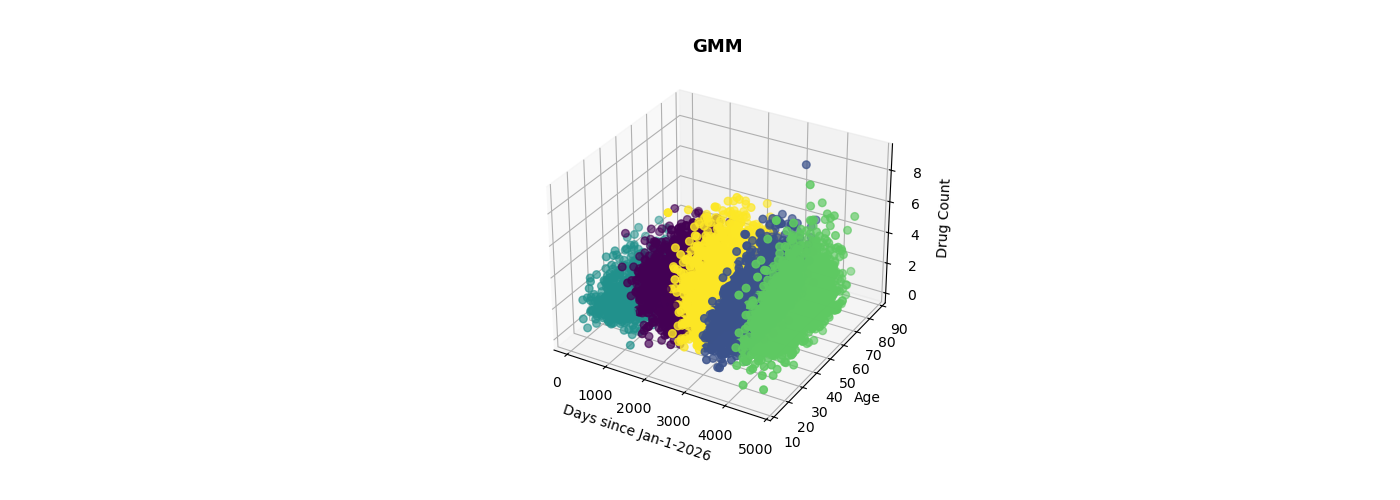

In [10]:
n = 5
gmm = GaussianMixture(n_components=n,        # K = n components
                       covariance_type='full', 
                       random_state=21)

labels_gmm = gmm.fit_predict(cleaned_adrd_df[['Days since 2012-Jan-01', 'Age', 'Drug Count']])

# fig, axes = plt.subplots(1, 1, figsize=(14, 5))
fig = plt.figure(figsize=(14, 5))
axes = fig.add_subplot(projection='3d')
axes.scatter(cleaned_adrd_df['Days since 2012-Jan-01'], cleaned_adrd_df['Age'], cleaned_adrd_df['Drug Count'], c=labels_gmm, s=30, cmap='viridis')
axes.set_xlabel("Days since Jan-1-2026")
axes.set_ylabel("Age")
axes.set_zlabel("Drug Count")
colors = plt.cm.viridis(np.linspace(0, 1, n))
# for k in range(n):
#     # Overlay the learned covariance ellipse for each component
    # draw_ellipse(axes, gmm.means_[k], gmm.covariances_[k], colors[k])
axes.set_title("GMM", fontweight='bold', fontsize=13);

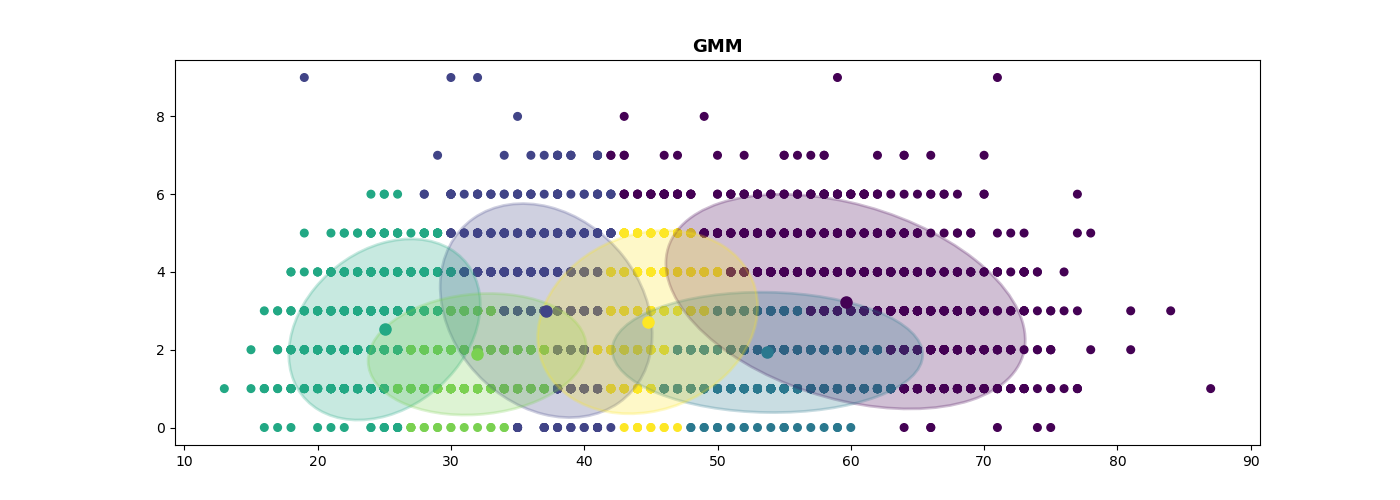

In [11]:
n = 6
gmm = GaussianMixture(n_components=n,        # K = n components
                       covariance_type='full', 
                       random_state=21)

labels_gmm = gmm.fit_predict(cleaned_adrd_df[['Age', 'Drug Count']])

fig, axes = plt.subplots(1, 1, figsize=(14, 5))
axes.scatter(cleaned_adrd_df['Age'], cleaned_adrd_df['Drug Count'], c=labels_gmm, s=30, cmap='viridis')
colors = plt.cm.viridis(np.linspace(0, 1, n))
for k in range(n):
#     # Overlay the learned covariance ellipse for each component
    draw_ellipse(axes, gmm.means_[k], gmm.covariances_[k], colors[k])
axes.set_title("GMM", fontweight='bold', fontsize=13);

# Trying PCA Now

In [12]:
cleaned_cod_df

,Cause,Cause Codes,Sex,Race,Year,Ten-Year Age Groups,Ten-Year Age Groups Code,Deaths,Population,Crude Rate
0,Drug poisonings (overdose) Unintentional (X40-...,D1,Female,American Indian or Alaska Native,1999.0,35-44 years,35-44,20.0,226197.0,8.8
1,Drug poisonings (overdose) Unintentional (X40-...,D1,Female,American Indian or Alaska Native,2000.0,35-44 years,35-44,19.0,236235.0,Unreliable
2,Drug poisonings (overdose) Unintentional (X40-...,D1,Female,American Indian or Alaska Native,2001.0,25-34 years,25-34,13.0,224905.0,Unreliable
3,Drug poisonings (overdose) Unintentional (X40-...,D1,Female,American Indian or Alaska Native,2001.0,35-44 years,35-44,15.0,242881.0,Unreliable
4,Drug poisonings (overdose) Unintentional (X40-...,D1,Female,American Indian or Alaska Native,2001.0,45-54 years,45-54,12.0,186923.0,Unreliable
...,...,...,...,...,...,...,...,...,...,...
2739,All other drug-induced causes,D9,Male,White,2020.0,45-54 years,45-54,518.0,15687816.0,3.3
2740,All other drug-induced causes,D9,Male,White,2020.0,55-64 years,55-64,550.0,16714227.0,3.3
2741,All other drug-induced causes,D9,Male,White,2020.0,65-74 years,65-74,249.0,12818362.0,1.9
2742,All other drug-induced causes,D9,Male,White,2020.0,75-84 years,75-84,70.0,6234692.0,1.1


In [14]:
male_cod_df = cleaned_cod_df[cleaned_cod_df['Sex'] == 'Male'][['Year', 'Race', 'Sex', 'Deaths', 'Population']]
male_cod_df = male_cod_df.groupby(['Year', 'Race'], as_index=False).agg({'Deaths':'sum', 'Population':'sum'})
male_cod_df['Crude Rate'] = male_cod_df["Deaths"] / male_cod_df["Population"] * 100000
male_cod_df

,Year,Race,Deaths,Population,Crude Rate
0,1999.0,American Indian or Alaska Native,62.0,807914.0,7.674084
1,1999.0,Asian or Pacific Islander,44.0,2608654.0,1.686694
2,1999.0,Black or African American,2138.0,38939874.0,5.490516
3,1999.0,White,10449.0,349226739.0,2.992039
4,2000.0,American Indian or Alaska Native,60.0,622562.0,9.637594
...,...,...,...,...,...
83,2019.0,White,40594.0,444316732.0,9.136275
84,2020.0,American Indian or Alaska Native,765.0,2399255.0,31.884898
85,2020.0,Asian or Pacific Islander,997.0,16936541.0,5.886680
86,2020.0,Black or African American,12005.0,69166586.0,17.356647


In [35]:
pca_matrix = male_cod_df.pivot(index='Race', columns='Year', values='Crude Rate')
pca_matrix

Year,1999.0,2000.0,2001.0,2002.0,2003.0,2004.0,2005.0,2006.0,2007.0,2008.0,...,2011.0,2012.0,2013.0,2014.0,2015.0,2016.0,2017.0,2018.0,2019.0,2020.0
Race,,,,,,,,,,,,,,,,,,,,,
American Indian or Alaska Native,7.674084,9.637594,7.744686,9.280675,10.746835,11.983192,12.025327,13.992385,11.620831,15.817162,...,14.158844,15.899430,15.701425,15.828669,20.282330,21.013112,25.853855,22.857804,21.936445,31.884898
Asian or Pacific Islander,1.686694,1.541189,1.483248,1.623383,2.040972,1.834887,2.227571,1.932320,1.947062,2.315782,...,2.303708,2.306712,2.780605,2.626281,4.057678,4.772126,3.593685,4.199262,4.176656,5.886680
Black or African American,5.490516,5.228323,5.670095,5.460956,5.371474,5.560169,5.959982,6.923141,5.835011,4.885616,...,5.057571,4.441312,5.029752,5.344128,6.384086,8.440056,11.630702,11.713441,13.504271,17.356647
White,2.992039,3.131211,3.325728,3.754879,4.178990,4.342515,4.698612,5.263352,5.229497,5.324568,...,5.793000,5.562055,6.080171,6.375063,6.969149,8.520354,8.660737,8.787327,9.136275,11.152933


In [38]:
row_means = pca_matrix.mean(axis=1)
print(row_means)
A_matrix = pca_matrix.sub(row_means, axis=0)
A_matrix

Race
American Indian or Alaska Native    15.802529
Asian or Pacific Islander            2.695570
Black or African American            7.019955
White                                5.905697
dtype: float64


Year,1999.0,2000.0,2001.0,2002.0,2003.0,2004.0,2005.0,2006.0,2007.0,2008.0,...,2011.0,2012.0,2013.0,2014.0,2015.0,2016.0,2017.0,2018.0,2019.0,2020.0
Race,,,,,,,,,,,,,,,,,,,,,
American Indian or Alaska Native,-8.128445,-6.164935,-8.057844,-6.521854,-5.055694,-3.819337,-3.777202,-1.810144,-4.181699,0.014633,...,-1.643685,0.096901,-0.101104,0.026140,4.479801,5.210583,10.051326,7.055275,6.133916,16.082368
Asian or Pacific Islander,-1.008877,-1.154381,-1.212323,-1.072187,-0.654598,-0.860683,-0.467999,-0.763250,-0.748508,-0.379788,...,-0.391862,-0.388858,0.085035,-0.069289,1.362108,2.076556,0.898115,1.503691,1.481086,3.191110
Black or African American,-1.529439,-1.791633,-1.349860,-1.558999,-1.648481,-1.459787,-1.059974,-0.096814,-1.184945,-2.134339,...,-1.962384,-2.578643,-1.990203,-1.675827,-0.635869,1.420101,4.610747,4.693485,6.484316,10.336692
White,-2.913658,-2.774486,-2.579969,-2.150818,-1.726707,-1.563182,-1.207085,-0.642345,-0.676200,-0.581129,...,-0.112697,-0.343642,0.174474,0.469366,1.063452,2.614657,2.755040,2.881630,3.230578,5.247236


In [43]:
U,S,Vt = np.linalg.svd(A_matrix)
Sd = np.zeros(A_matrix.shape)
np.fill_diagonal(Sd,S)
np.allclose(U@Sd@Vt, A_matrix)
# S

True

In [45]:
r=4
A = U[:, :r] @ Sd[:r, :r] @ Vt[:r, :]
A

array([[-8.12844508e+00, -6.16493487e+00, -8.05784360e+00,
        -6.52185373e+00, -5.05569379e+00, -3.81933670e+00,
        -3.77720201e+00, -1.81014392e+00, -4.18169855e+00,
         1.46332311e-02,  1.49531991e+00, -1.38432114e+00,
        -1.64368504e+00,  9.69008929e-02, -1.01104328e-01,
         2.61397621e-02,  4.47980083e+00,  5.21058298e+00,
         1.00513259e+01,  7.05527529e+00,  6.13391557e+00,
         1.60823684e+01],
       [-1.00887652e+00, -1.15438130e+00, -1.21232259e+00,
        -1.07218741e+00, -6.54597760e-01, -8.60683453e-01,
        -4.67998694e-01, -7.63250102e-01, -7.48508127e-01,
        -3.79788463e-01, -6.47040073e-01, -7.78058067e-01,
        -3.91861734e-01, -3.88857712e-01,  8.50349895e-02,
        -6.92893960e-02,  1.36210805e+00,  2.07655618e+00,
         8.98114527e-01,  1.50369142e+00,  1.48108618e+00,
         3.19111005e+00],
       [-1.52943922e+00, -1.79163261e+00, -1.34986032e+00,
        -1.55899939e+00, -1.64848099e+00, -1.45978664e+00,
    